In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
pd.set_option("display.max_rows", None)
sns.set_theme(style="whitegrid", font="serif", font_scale=0.6)

In [3]:
gold_df = pd.read_parquet(
    r"C:\MSDA\D610 (capstone)\Airport Congestion Prediction System\Task 2\Airport Congestion Prediction System\data\output\transformed\airport_congestion_gold"
)

### SECTION 1 - Dataset Overview

##### Row Counts

In [4]:
print(f"Total rows: {len(gold_df)}\n")

unique_iata_code = gold_df['iata_code'].unique()
print(f"Total unique airports:\n{len(unique_iata_code)}")
print(f"Unique airports:\n{unique_iata_code}\n")

unique_years = gold_df['year'].unique()
print(f"Total unique years:\n{len(unique_years)}")
print(f"Unique years:\n{unique_years}\n")

unique_year_months = sorted(
    (gold_df['year'].astype(str) + "-" + gold_df['month'].astype(str)).unique()
)
print(f"Unique year-month combinations: {unique_year_months}\n")

count_by_year = gold_df['year'].value_counts()
print(f"Total rows per year: {count_by_year}\n")

count_by_iata = gold_df['iata_code'].value_counts()
print(f"Total rows per airport: {count_by_iata}")

Total rows: 11050

Total unique airports:
337
Unique airports:
['ABI' 'ABQ' 'ABR' 'ABY' 'ACK' 'ADK' 'ADQ' 'AGS' 'ALB' 'ALO' 'ANC' 'APN'
 'ART' 'ASE' 'ATL' 'ATW' 'AZO' 'BDL' 'BET' 'BFL' 'BGM' 'BGR' 'BHM' 'BIL'
 'BIS' 'BKG' 'BLI' 'BMI' 'BNA' 'BOI' 'BOS' 'BPT' 'BQK' 'BQN' 'BRD' 'BRO'
 'BTM' 'BTR' 'BTV' 'BUF' 'BUR' 'BWI' 'BZN' 'CAE' 'CAK' 'CEC' 'CHA' 'CHS'
 'CIC' 'CIU' 'CLD' 'CLE' 'CLT' 'CMH' 'CMI' 'CMX' 'COD' 'COU' 'CPR' 'CRP'
 'CRW' 'CSG' 'CVG' 'CWA' 'DAB' 'DAL' 'DAY' 'DCA' 'DEN' 'DFW' 'DHN' 'DLH'
 'DRO' 'DRT' 'DSM' 'DTW' 'EAU' 'ECP' 'EGE' 'EKO' 'ELM' 'ERI' 'ESC' 'EUG'
 'EVV' 'EWN' 'EWR' 'FAR' 'FAT' 'FCA' 'FLG' 'FLL' 'FSD' 'FSM' 'FWA' 'GCC'
 'GCK' 'GEG' 'GGG' 'GNV' 'GPT' 'GRB' 'GRI' 'GRK' 'GRR' 'GSO' 'GSP' 'GST'
 'GTF' 'GTR' 'GUC' 'GUM' 'HIB' 'HLN' 'HNL' 'HOU' 'HPN' 'HRL' 'IAD' 'IAH'
 'ICT' 'ILM' 'IMT' 'INL' 'ISP' 'ITH' 'ITO' 'IYK' 'JAC' 'JAN' 'JFK' 'JLN'
 'KOA' 'KTN' 'LAN' 'LAS' 'LAX' 'LFT' 'LGA' 'LGB' 'LIH' 'LIT' 'LMT' 'LNK'
 'LRD' 'LWS' 'MAF' 'MBS' 'MCI' 'MCO' 'MDT' 'MDW' 'MEM' 'MFE' 

##### Schema Inspection

In [5]:
gold_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11050 entries, 0 to 11049
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   iata_code                  11050 non-null  object  
 1   month                      11050 non-null  int32   
 2   total_flights              11050 non-null  int64   
 3   avg_departure_delay        11050 non-null  float64 
 4   avg_arrival_delay          11049 non-null  float64 
 5   delay_rate                 11050 non-null  float64 
 6   cancellation_rate          11050 non-null  float64 
 7   avg_carrier_delay          11050 non-null  float64 
 8   avg_weather_delay          11050 non-null  float64 
 9   avg_nas_delay              11050 non-null  float64 
 10  avg_security_delay         11050 non-null  float64 
 11  avg_late_aircraft_delay    11050 non-null  float64 
 12  avg_taxi_out_time          11050 non-null  float64 
 13  avg_taxi_in_time           1104

### SECTION 2 - Data Quality

##### Duplicate Composite Primary Key Check

In [6]:
composite_pk = ["iata_code", "year", "month"]

duplicate_keys = (
    gold_df
    .groupby(composite_pk)
    .size()
    .reset_index(name="count")
)

duplicate_keys[duplicate_keys["count"] > 1]

C:\Users\kyuen\AppData\Local\Temp\ipykernel_30220\2053627411.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(composite_pk)


,iata_code,year,month,count


##### Null Analysis

In [7]:
null_count = gold_df.isna().sum()
print(f"Null count:\n{null_count}")

Null count:
iata_code                       0
month                           0
total_flights                   0
avg_departure_delay             0
avg_arrival_delay               1
delay_rate                      0
cancellation_rate               0
avg_carrier_delay               0
avg_weather_delay               0
avg_nas_delay                   0
avg_security_delay              0
avg_late_aircraft_delay         0
avg_taxi_out_time               0
avg_taxi_in_time                1
avg_total_taxi_time             1
total_passenger_count        4866
avg_wait_time_minutes        7924
avg_temperature              8268
total_precipitation          8257
total_snowfall               9147
passenger_to_flight_ratio    4866
year                            0
dtype: int64


In [8]:
columns = [
    'avg_arrival_delay',
    'avg_taxi_in_time',
    'avg_total_taxi_time',
    'total_passenger_count',
    'avg_wait_time_minutes',
    'avg_temperature',
    'total_precipitation',
    'total_snowfall',
    'passenger_to_flight_ratio'
]

for column in columns:
    null_count = gold_df.groupby('year')[column].apply(lambda x: x.isnull().sum())
    print(f"Null count by {column}:\n{null_count}\n")

Null count by avg_arrival_delay:
year
2013    1
2014    0
2015    0
Name: avg_arrival_delay, dtype: int64

Null count by avg_taxi_in_time:
year
2013    1
2014    0
2015    0
Name: avg_taxi_in_time, dtype: int64

Null count by avg_total_taxi_time:
year
2013    1
2014    0
2015    0
Name: avg_total_taxi_time, dtype: int64

Null count by total_passenger_count:
year
2013    3660
2014    1050
2015     156
Name: total_passenger_count, dtype: int64

Null count by avg_wait_time_minutes:
year
2013    2629
2014    2648
2015    2647
Name: avg_wait_time_minutes, dtype: int64

Null count by avg_temperature:
year
2013    2715
2014    2768
2015    2785
Name: avg_temperature, dtype: int64

Null count by total_precipitation:
year
2013    2711
2014    2761
2015    2785
Name: total_precipitation, dtype: int64

Null count by total_snowfall:
year
2013    3001
2014    3075
2015    3071
Name: total_snowfall, dtype: int64

Null count by passenger_to_flight_ratio:
year
2013    3660
2014    1050
2015     156
Na

C:\Users\kyuen\AppData\Local\Temp\ipykernel_30220\4290377459.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  null_count = gold_df.groupby('year')[column].apply(lambda x: x.isnull().sum())


In [9]:
columns = [
    'avg_arrival_delay',
    'avg_taxi_in_time',
    'avg_total_taxi_time',
    'total_passenger_count',
    'avg_wait_time_minutes',
    'avg_temperature',
    'total_precipitation',
    'total_snowfall',
    'passenger_to_flight_ratio'
]

year_month = gold_df['year'].astype(str) + "-" + gold_df['month'].astype(str)

for column in columns:
    null_count = gold_df.groupby(year_month)[column].apply(lambda x: x.isnull().sum())
    print(f"Null count by {column}:\n{null_count}\n")

Null count by avg_arrival_delay:
2013-1     0
2013-10    0
2013-11    0
2013-12    0
2013-2     0
2013-3     0
2013-4     0
2013-5     0
2013-6     1
2013-7     0
2013-8     0
2013-9     0
2014-1     0
2014-10    0
2014-11    0
2014-12    0
2014-2     0
2014-3     0
2014-4     0
2014-5     0
2014-6     0
2014-7     0
2014-8     0
2014-9     0
2015-1     0
2015-10    0
2015-11    0
2015-12    0
2015-2     0
2015-3     0
2015-4     0
2015-5     0
2015-6     0
2015-7     0
2015-8     0
2015-9     0
Name: avg_arrival_delay, dtype: int64

Null count by avg_taxi_in_time:
2013-1     0
2013-10    0
2013-11    0
2013-12    0
2013-2     0
2013-3     0
2013-4     0
2013-5     0
2013-6     1
2013-7     0
2013-8     0
2013-9     0
2014-1     0
2014-10    0
2014-11    0
2014-12    0
2014-2     0
2014-3     0
2014-4     0
2014-5     0
2014-6     0
2014-7     0
2014-8     0
2014-9     0
2015-1     0
2015-10    0
2015-11    0
2015-12    0
2015-2     0
2015-3     0
2015-4     0
2015-5     0
2015-6     0

In [10]:
null_percentage = gold_df.isnull().mean() * 100

print(f"Null percentage:\n{round(null_percentage, 2)}")

Null percentage:
iata_code                     0.00
month                         0.00
total_flights                 0.00
avg_departure_delay           0.00
avg_arrival_delay             0.01
delay_rate                    0.00
cancellation_rate             0.00
avg_carrier_delay             0.00
avg_weather_delay             0.00
avg_nas_delay                 0.00
avg_security_delay            0.00
avg_late_aircraft_delay       0.00
avg_taxi_out_time             0.00
avg_taxi_in_time              0.01
avg_total_taxi_time           0.01
total_passenger_count        44.04
avg_wait_time_minutes        71.71
avg_temperature              74.82
total_precipitation          74.72
total_snowfall               82.78
passenger_to_flight_ratio    44.04
year                          0.00
dtype: float64


In [11]:
columns = [
    'avg_arrival_delay',
    'avg_taxi_in_time',
    'avg_total_taxi_time',
    'total_passenger_count',
    'avg_wait_time_minutes',
    'avg_temperature',
    'total_precipitation',
    'total_snowfall',
    'passenger_to_flight_ratio'
]

for column in columns:
    null_percentage = gold_df.groupby('year')[column].apply(lambda x: x.isnull().mean() * 100)
    print(f"Null percentage by {column}:\n{round(null_percentage, 2)}\n")

Null percentage by avg_arrival_delay:
year
2013    0.03
2014    0.00
2015    0.00
Name: avg_arrival_delay, dtype: float64

Null percentage by avg_taxi_in_time:
year
2013    0.03
2014    0.00
2015    0.00
Name: avg_taxi_in_time, dtype: float64

Null percentage by avg_total_taxi_time:
year
2013    0.03
2014    0.00
2015    0.00
Name: avg_total_taxi_time, dtype: float64

Null percentage by total_passenger_count:
year
2013    100.00
2014     28.46
2015      4.22
Name: total_passenger_count, dtype: float64

Null percentage by avg_wait_time_minutes:
year
2013    71.83
2014    71.76
2015    71.54
Name: avg_wait_time_minutes, dtype: float64

Null percentage by avg_temperature:
year
2013    74.18
2014    75.01
2015    75.27
Name: avg_temperature, dtype: float64

Null percentage by total_precipitation:
year
2013    74.07
2014    74.82
2015    75.27
Name: total_precipitation, dtype: float64

Null percentage by total_snowfall:
year
2013    81.99
2014    83.33
2015    83.00
Name: total_snowfall, dt

C:\Users\kyuen\AppData\Local\Temp\ipykernel_30220\3708979632.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  null_percentage = gold_df.groupby('year')[column].apply(lambda x: x.isnull().mean() * 100)


In [12]:
columns = [
    'avg_arrival_delay',
    'avg_taxi_in_time',
    'avg_total_taxi_time',
    'total_passenger_count',
    'avg_wait_time_minutes',
    'avg_temperature',
    'total_precipitation',
    'total_snowfall',
    'passenger_to_flight_ratio'
]

year_month = gold_df['year'].astype(str) + "-" + gold_df['month'].astype(str)

for column in columns:
    null_percentage = gold_df.groupby(year_month)[column].apply(lambda x: x.isnull().mean() * 100)
    print(f"Null percentage by {column}:\n{round(null_percentage, 2)}\n")

Null percentage by avg_arrival_delay:
2013-1     0.00
2013-10    0.00
2013-11    0.00
2013-12    0.00
2013-2     0.00
2013-3     0.00
2013-4     0.00
2013-5     0.00
2013-6     0.32
2013-7     0.00
2013-8     0.00
2013-9     0.00
2014-1     0.00
2014-10    0.00
2014-11    0.00
2014-12    0.00
2014-2     0.00
2014-3     0.00
2014-4     0.00
2014-5     0.00
2014-6     0.00
2014-7     0.00
2014-8     0.00
2014-9     0.00
2015-1     0.00
2015-10    0.00
2015-11    0.00
2015-12    0.00
2015-2     0.00
2015-3     0.00
2015-4     0.00
2015-5     0.00
2015-6     0.00
2015-7     0.00
2015-8     0.00
2015-9     0.00
Name: avg_arrival_delay, dtype: float64

Null percentage by avg_taxi_in_time:
2013-1     0.00
2013-10    0.00
2013-11    0.00
2013-12    0.00
2013-2     0.00
2013-3     0.00
2013-4     0.00
2013-5     0.00
2013-6     0.32
2013-7     0.00
2013-8     0.00
2013-9     0.00
2014-1     0.00
2014-10    0.00
2014-11    0.00
2014-12    0.00
2014-2     0.00
2014-3     0.00
2014-4     0.00
2014

##### Outlier Detection (IQR)

In [13]:
def detect_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    return outliers


outlier_columns = [                                  
    'avg_departure_delay',         
    'avg_arrival_delay',                    
    'avg_carrier_delay',         
    'avg_weather_delay',           
    'avg_nas_delay',               
    'avg_security_delay',          
    'avg_late_aircraft_delay',        
    'total_passenger_count',                
    'total_snowfall'         
]

for col in outlier_columns:
    outliers_delay = detect_outliers(gold_df, col)
    print(f"Number of outliers ({col}): {len(outliers_delay)}")

Number of outliers (avg_departure_delay): 422
Number of outliers (avg_arrival_delay): 482
Number of outliers (avg_carrier_delay): 508
Number of outliers (avg_weather_delay): 1199
Number of outliers (avg_nas_delay): 521
Number of outliers (avg_security_delay): 1622
Number of outliers (avg_late_aircraft_delay): 425
Number of outliers (total_passenger_count): 948
Number of outliers (total_snowfall): 337


### SECTION 3 - Descriptive Statistics

##### Mean, Median, and Mode

In [14]:
columns = [                     
    'total_flights',               
    'avg_departure_delay',         
    'avg_arrival_delay',           
    'delay_rate',                  
    'cancellation_rate',           
    'avg_carrier_delay',         
    'avg_weather_delay',           
    'avg_nas_delay',               
    'avg_security_delay',          
    'avg_late_aircraft_delay',     
    'avg_taxi_out_time',           
    'avg_taxi_in_time',            
    'avg_total_taxi_time',         
    'total_passenger_count',       
    'avg_wait_time_minutes',       
    'avg_temperature',             
    'total_precipitation',         
    'total_snowfall',              
    'passenger_to_flight_ratio',   
]

means = [gold_df[column].mean() for column in columns]
medians = [gold_df[column].median() for column in columns]
modes = [gold_df[column].mode() for column in columns]

print("Mean")
for column, mean in zip(columns, means):
    print(f"{column}: {mean}")

print("\nMedian")
for column, median in zip(columns, medians):
    print(f"{column}: {median}")

print("\nMode")
for column, mode in zip(columns, modes):
    print(f"{column}: {mode}")

Mean
total_flights: 1092.887963800905
avg_departure_delay: 7.763799999999999
avg_arrival_delay: 5.186349895918183
delay_rate: 0.16495203619909504
cancellation_rate: 0.02698371040723982
avg_carrier_delay: 3.0318859728506786
avg_weather_delay: 0.5029936651583711
avg_nas_delay: 2.752476018099548
avg_security_delay: 0.03515837104072398
avg_late_aircraft_delay: 5.0048126696832576
avg_taxi_out_time: 13.52879366515837
avg_taxi_in_time: 8.2796596977102
avg_total_taxi_time: 21.808997194316227
total_passenger_count: 134479.2478978008
avg_wait_time_minutes: 4.977389635316698
avg_temperature: 13.59196980589504
total_precipitation: 81.5436448263516
total_snowfall: 74.11350499211771
passenger_to_flight_ratio: 144.50209734799483

Median
total_flights: 181.5
avg_departure_delay: 7.06
avg_arrival_delay: 4.23
delay_rate: 0.16
cancellation_rate: 0.01
avg_carrier_delay: 2.36
avg_weather_delay: 0.09
avg_nas_delay: 2.14
avg_security_delay: 0.0
avg_late_aircraft_delay: 4.33
avg_taxi_out_time: 13.094999999999

In [15]:
gold_df[columns].describe()

,total_flights,avg_departure_delay,avg_arrival_delay,delay_rate,cancellation_rate,avg_carrier_delay,avg_weather_delay,avg_nas_delay,avg_security_delay,avg_late_aircraft_delay,avg_taxi_out_time,avg_taxi_in_time,avg_total_taxi_time,total_passenger_count,avg_wait_time_minutes,avg_temperature,total_precipitation,total_snowfall,passenger_to_flight_ratio
count,11050.000000,11050.000000,11049.000000,11050.000000,11050.000000,11050.000000,11050.000000,11050.000000,11050.000000,11050.000000,11050.000000,11049.000000,11049.000000,6.184000e+03,3126.000000,2782.000000,2793.000000,1903.000000,6184.000000
mean,1092.887964,7.763800,5.186350,0.164952,0.026984,3.031886,0.502994,2.752476,0.035158,5.004813,13.528794,8.279660,21.808997,1.344792e+05,4.977390,13.591970,81.543645,74.113505,144.502097
std,2604.408485,9.089785,10.267886,0.088524,0.041525,4.059419,1.319719,3.305040,0.535678,4.644610,3.466552,2.482031,4.524976,3.334115e+05,8.487694,10.235061,76.190665,163.670139,352.702889
min,1.000000,-22.640000,-33.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,5.000000,4.700000e+01,1.000000,-16.760000,0.000000,0.000000,2.660000
25%,52.000000,2.840000,-0.380000,0.110000,0.000000,0.930000,0.000000,1.110000,0.000000,2.580000,11.470000,6.860000,19.310000,3.580500e+03,1.000000,7.100000,25.500000,0.000000,45.367500
50%,181.500000,7.060000,4.230000,0.160000,0.010000,2.360000,0.090000,2.140000,0.000000,4.330000,13.095000,8.090000,21.710000,1.663400e+04,2.225000,15.510000,62.000000,0.000000,87.005000
75%,674.750000,11.490000,9.410000,0.210000,0.030000,3.890000,0.470000,3.550000,0.000000,6.510000,15.220000,9.370000,24.180000,8.283400e+04,5.000000,21.545000,113.800000,53.000000,169.322500
max,26854.000000,234.750000,239.500000,1.000000,0.640000,144.400000,27.520000,160.880000,26.570000,232.750000,35.000000,47.600000,63.700000,3.442080e+06,145.500000,31.170000,488.800000,1524.000000,19441.000000


##### Standard Deviation & Cofficient of Variation (CV)

In [16]:
columns = [                     
    'total_flights',               
    'avg_departure_delay',         
    'avg_arrival_delay',           
    'delay_rate',                  
    'cancellation_rate',           
    'avg_carrier_delay',         
    'avg_weather_delay',           
    'avg_nas_delay',               
    'avg_security_delay',          
    'avg_late_aircraft_delay',     
    'avg_taxi_out_time',           
    'avg_taxi_in_time',            
    'avg_total_taxi_time',         
    'total_passenger_count',       
    'avg_wait_time_minutes',       
    'avg_temperature',             
    'total_precipitation',         
    'total_snowfall',              
    'passenger_to_flight_ratio',   
]

column_std_d = {}

for column in columns:
    std_d = gold_df[column].std()

    column_std_d[column] = std_d

###### Standard Deviation

In [17]:
# Standard deviation measures the variability or dispersion of a feature around its mean. 
# High standard deviation = values vary a lot
for column, std_d in column_std_d.items():
    print(f"Standard Deviation ({column}):\n{std_d}")

# Interpretation:
## example
### total_flights - the number of flights varies substantially from the average number of flights because of seasonality, large airports vs small airports
### avg_departure_delay - values less vary

Standard Deviation (total_flights):
2604.40848543228
Standard Deviation (avg_departure_delay):
9.089784607467596
Standard Deviation (avg_arrival_delay):
10.267886333713745
Standard Deviation (delay_rate):
0.08852356641055886
Standard Deviation (cancellation_rate):
0.041524665695854245
Standard Deviation (avg_carrier_delay):
4.059418802183816
Standard Deviation (avg_weather_delay):
1.3197187218158541
Standard Deviation (avg_nas_delay):
3.3050395434758633
Standard Deviation (avg_security_delay):
0.535677853115024
Standard Deviation (avg_late_aircraft_delay):
4.644609742670471
Standard Deviation (avg_taxi_out_time):
3.4665519583330107
Standard Deviation (avg_taxi_in_time):
2.482030993570983
Standard Deviation (avg_total_taxi_time):
4.524976429150703
Standard Deviation (total_passenger_count):
333411.4516181171
Standard Deviation (avg_wait_time_minutes):
8.487693986932697
Standard Deviation (avg_temperature):
10.235061023167153
Standard Deviation (total_precipitation):
76.19066466238593
St

###### Coefficient of Variation (CV)

In [18]:
# Putting it together to interpret variability between columns 
# std / mean = CV

# | CV Range  | Interpretation             |
# | --------- | -------------------------- |
# | < 0.1     | Very low variability       |
# | 0.1 – 0.3 | Low variability            |
# | 0.3 – 0.5 | Moderate variability       |
# | 0.5 – 1.0 | High variability           |
# | > 1.0     | Extremely high variability |

for column, std_d in column_std_d.items():
    mean = gold_df[column].mean()
    cv = std_d / mean
    print(f"Coefficient of Variation ({column}): {cv}")

# example
## total_flights - values greatly fluctuate
## avg_total_taxi_time - values tightly clustered around the mean

Coefficient of Variation (total_flights): 2.3830516683288625
Coefficient of Variation (avg_departure_delay): 1.1707906704793525
Coefficient of Variation (avg_arrival_delay): 1.9797905154441833
Coefficient of Variation (delay_rate): 0.5366624653466662
Coefficient of Variation (cancellation_rate): 1.5388790151228808
Coefficient of Variation (avg_carrier_delay): 1.3389087975386547
Coefficient of Variation (avg_weather_delay): 2.62372831554515
Coefficient of Variation (avg_nas_delay): 1.2007514404277477
Coefficient of Variation (avg_security_delay): 15.236139708934404
Coefficient of Variation (avg_late_aircraft_delay): 0.9280286894263351
Coefficient of Variation (avg_taxi_out_time): 0.2562351118755444
Coefficient of Variation (avg_taxi_in_time): 0.299774517817128
Coefficient of Variation (avg_total_taxi_time): 0.20748209506533313
Coefficient of Variation (total_passenger_count): 2.479278080670836
Coefficient of Variation (avg_wait_time_minutes): 1.7052500625446108
Coefficient of Variation 

##### Percentile Analysis

In [19]:
numeric_cols = gold_df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    print(f"\n{col}")
    print(
        gold_df[col].quantile(
            [0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
        )
    )


month
0.25     4.0
0.50     7.0
0.75     9.0
0.90    11.0
0.95    12.0
0.99    12.0
Name: month, dtype: float64

total_flights
0.25       52.00
0.50      181.50
0.75      674.75
0.90     3047.00
0.95     6151.75
0.99    13035.66
Name: total_flights, dtype: float64

avg_departure_delay
0.25     2.8400
0.50     7.0600
0.75    11.4900
0.90    16.8210
0.95    21.1200
0.99    36.3363
Name: avg_departure_delay, dtype: float64

avg_arrival_delay
0.25    -0.3800
0.50     4.2300
0.75     9.4100
0.90    15.8500
0.95    21.3160
0.99    37.7056
Name: avg_arrival_delay, dtype: float64

delay_rate
0.25    0.1100
0.50    0.1600
0.75    0.2100
0.90    0.2700
0.95    0.3100
0.99    0.4451
Name: delay_rate, dtype: float64

cancellation_rate
0.25    0.00
0.50    0.01
0.75    0.03
0.90    0.07
0.95    0.10
0.99    0.20
Name: cancellation_rate, dtype: float64

avg_carrier_delay
0.25     0.9300
0.50     2.3600
0.75     3.8900
0.90     5.9500
0.95     8.0200
0.99    17.3006
Name: avg_carrier_delay, dtype: f

##### Skewness

In [20]:
# Is data balanced around the mean? Any outliers? Any extreme values pull the distribution left or right?
#
# | Skewness Value | Interpretation          |
# | -------------- | ----------------------- |
# | ≈ 0            | symmetric / normal-like |
# | -0.5 to 0.5    | approximately symmetric |
# | 0.5 to 1       | moderately skewed       |
# | > 1            | highly skewed           |
# | < -1           | highly left-skewed      |


skew_values = gold_df.skew(numeric_only=True)
print(f"Skewness\n{skew_values}")

# Interpretation:
## avg_departure_delay - right-skewed = most airports/months have normal departure delays, with only a few airports/months have extreme delays

Skewness
month                         0.000502
total_flights                 4.512736
avg_departure_delay           3.959827
avg_arrival_delay             3.450839
delay_rate                    1.512981
cancellation_rate             4.089063
avg_carrier_delay             9.407572
avg_weather_delay             7.905239
avg_nas_delay                15.137753
avg_security_delay           32.116871
avg_late_aircraft_delay      13.343797
avg_taxi_out_time             0.896552
avg_taxi_in_time              2.174027
avg_total_taxi_time           0.459152
total_passenger_count         4.328049
avg_wait_time_minutes         7.137416
avg_temperature              -0.647222
total_precipitation           1.759955
total_snowfall                3.027233
passenger_to_flight_ratio    30.678220
dtype: float64


##### Min and Max

In [21]:
columns = [col for col in columns if col != "month"]

for col in columns:
    print(f"Max ({col}): {gold_df[col].max()}")
    print(f"Min ({col}): {gold_df[col].min()}\n")

Max (total_flights): 26854
Min (total_flights): 1

Max (avg_departure_delay): 234.75
Min (avg_departure_delay): -22.64

Max (avg_arrival_delay): 239.5
Min (avg_arrival_delay): -33.0

Max (delay_rate): 1.0
Min (delay_rate): 0.0

Max (cancellation_rate): 0.64
Min (cancellation_rate): 0.0

Max (avg_carrier_delay): 144.4
Min (avg_carrier_delay): 0.0

Max (avg_weather_delay): 27.52
Min (avg_weather_delay): 0.0

Max (avg_nas_delay): 160.88
Min (avg_nas_delay): 0.0

Max (avg_security_delay): 26.57
Min (avg_security_delay): 0.0

Max (avg_late_aircraft_delay): 232.75
Min (avg_late_aircraft_delay): 0.0

Max (avg_taxi_out_time): 35.0
Min (avg_taxi_out_time): 1.0

Max (avg_taxi_in_time): 47.6
Min (avg_taxi_in_time): 2.0

Max (avg_total_taxi_time): 63.7
Min (avg_total_taxi_time): 5.0

Max (total_passenger_count): 3442080.0
Min (total_passenger_count): 47.0

Max (avg_wait_time_minutes): 145.5
Min (avg_wait_time_minutes): 1.0

Max (avg_temperature): 31.17
Min (avg_temperature): -16.76

Max (total_pre

### SECTION 4 - Univariate Analysis

##### Histograms

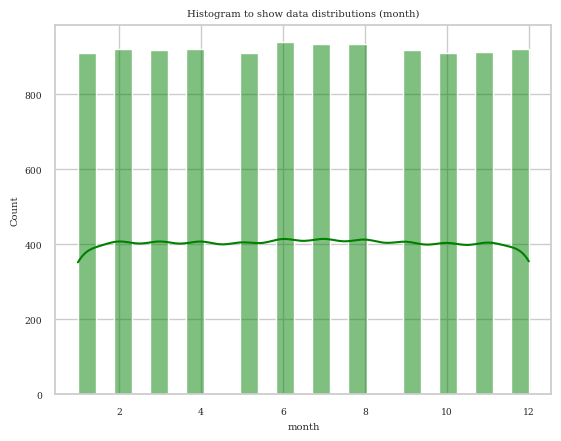

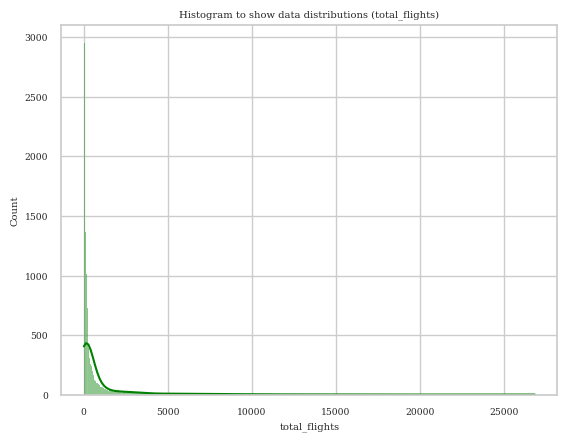

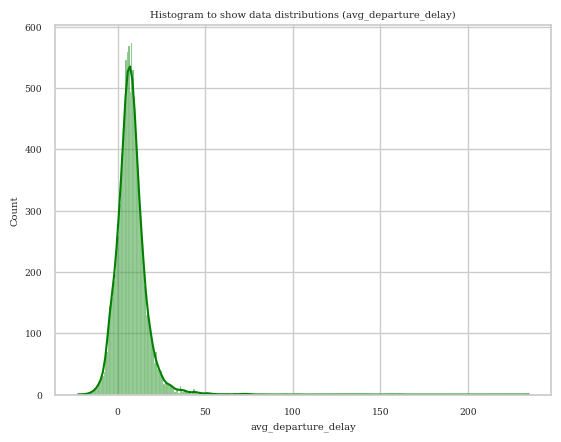

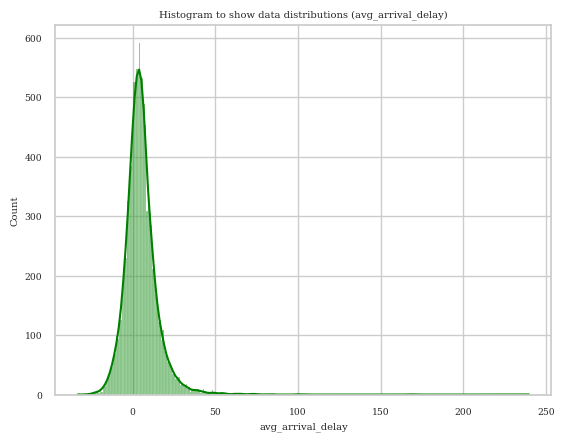

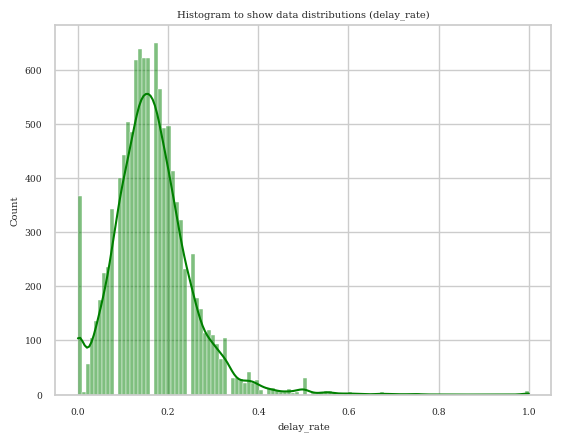

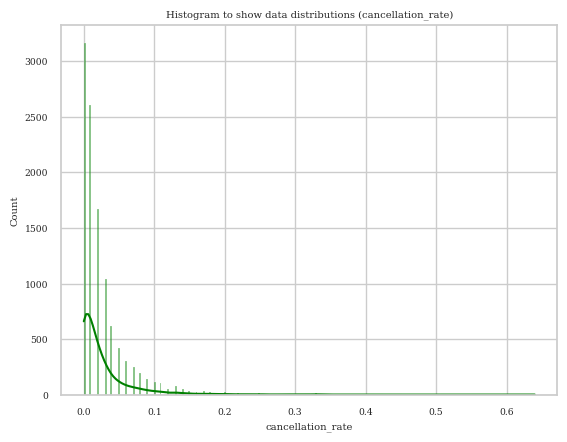

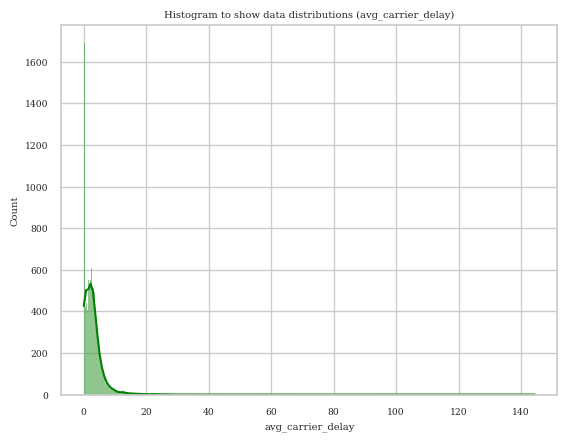

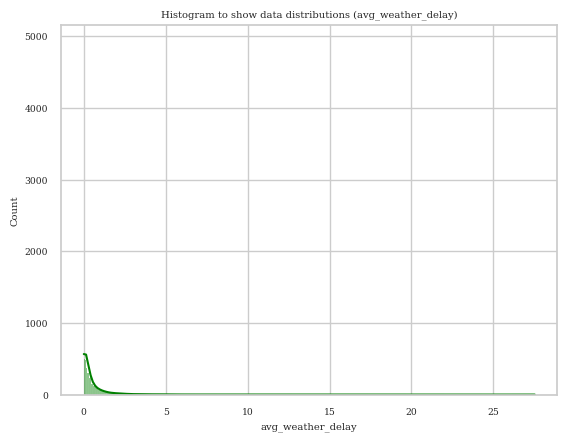

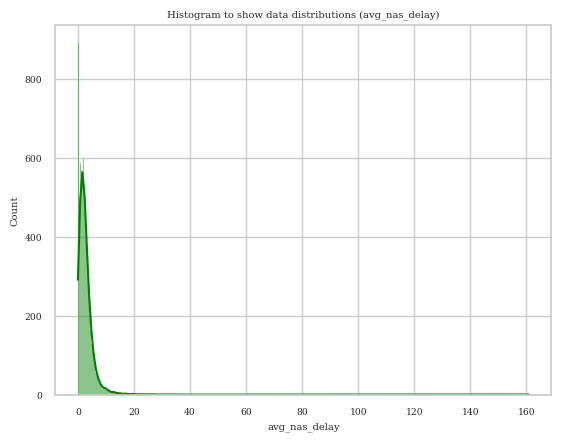

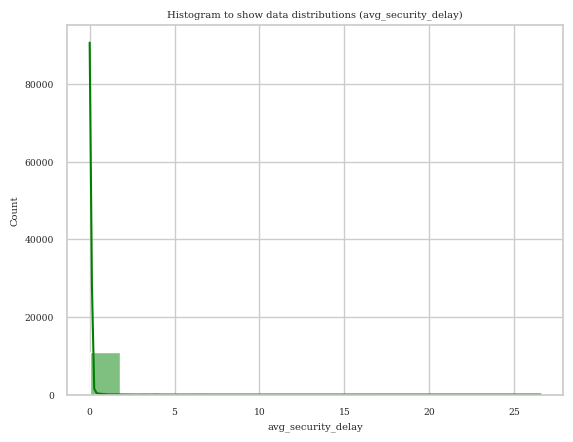

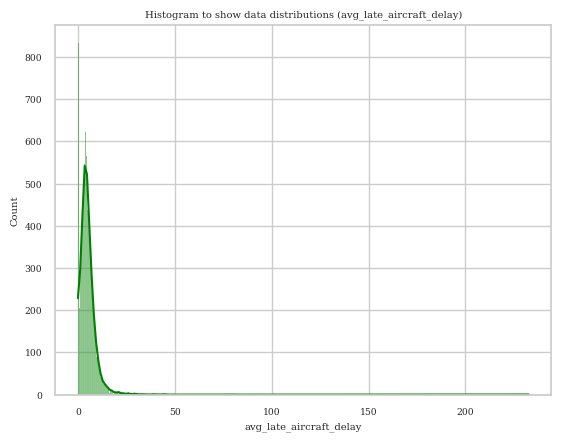

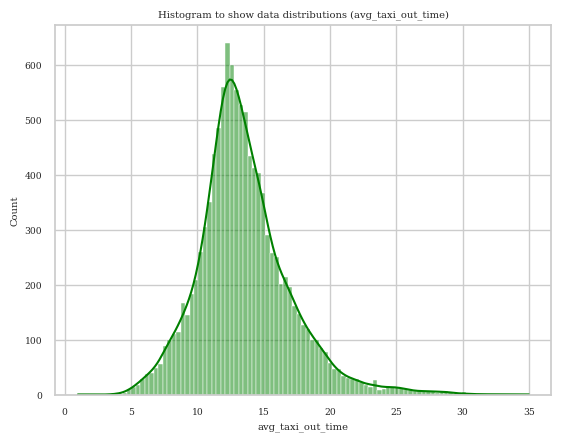

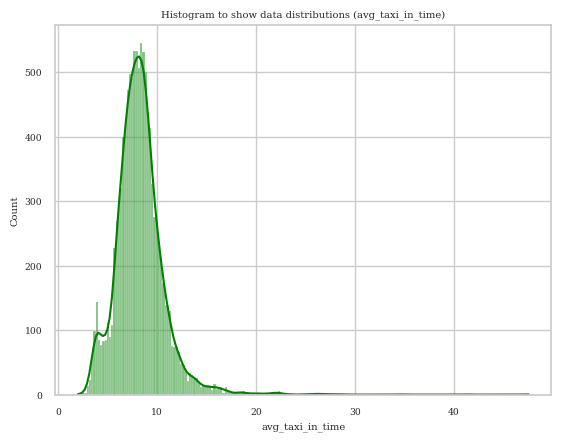

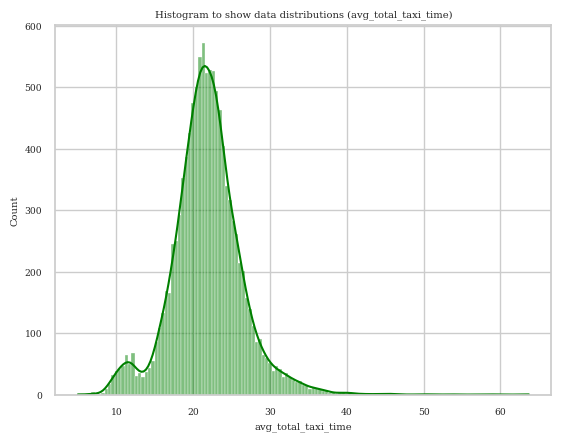

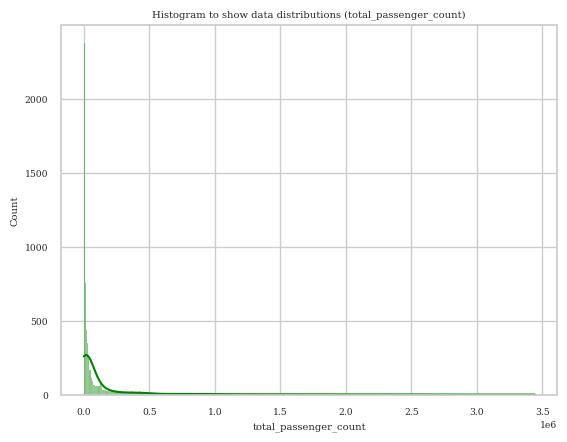

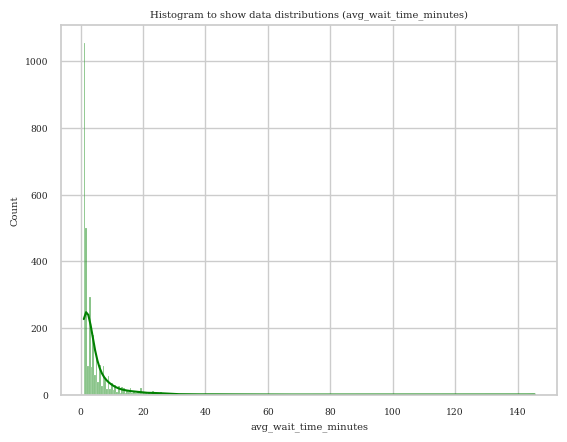

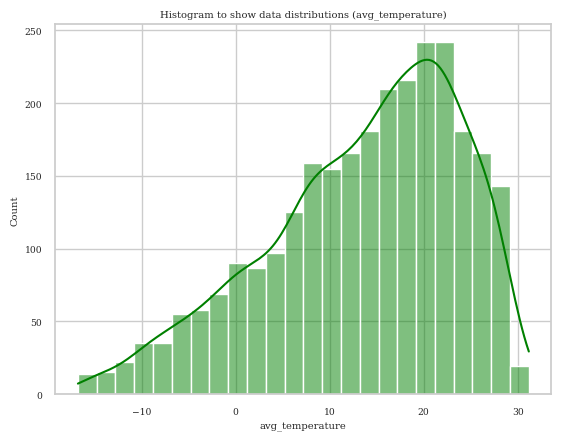

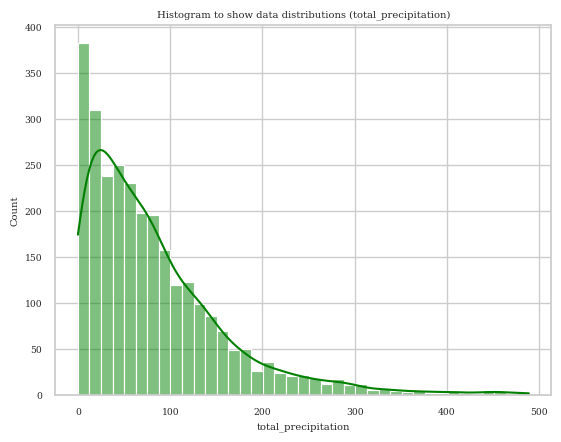

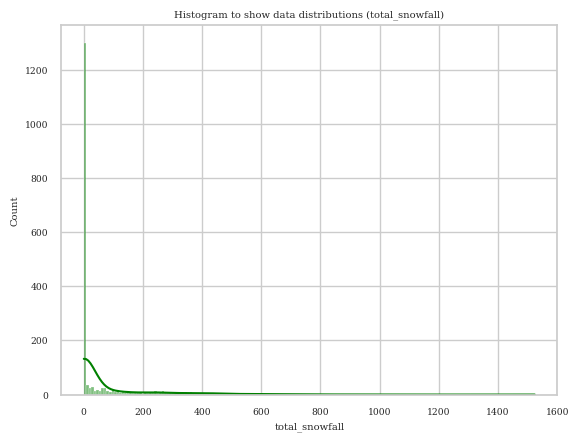

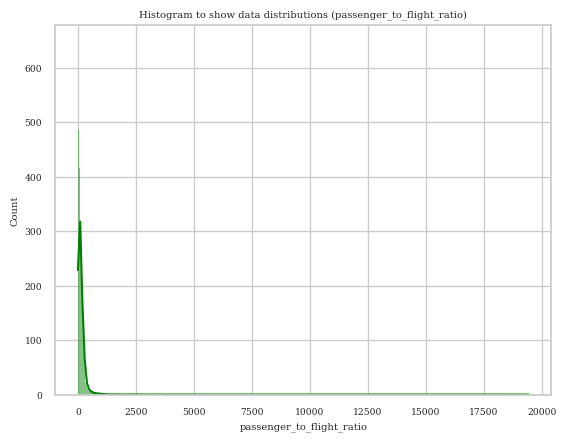

In [22]:
columns = ["month"] + columns

for col in columns:
    sns.histplot(gold_df[col], kde=True, color='green')
    plt.title(f"Histogram to show data distributions ({col})")
    plt.show()

##### Box Plots

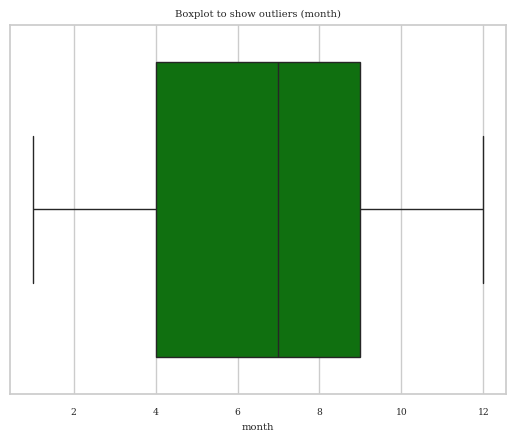

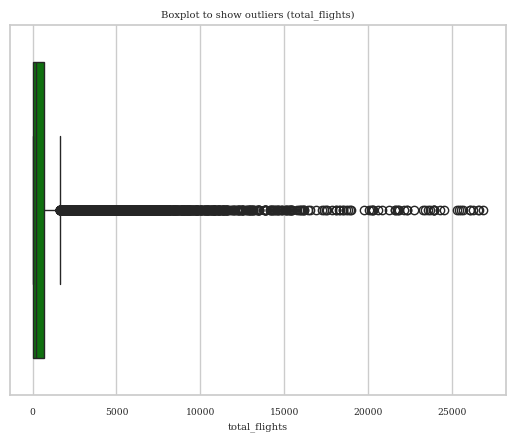

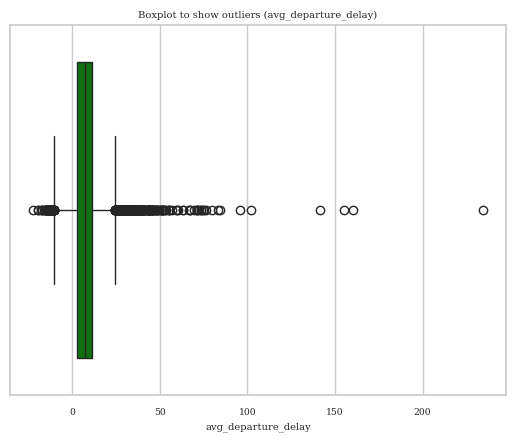

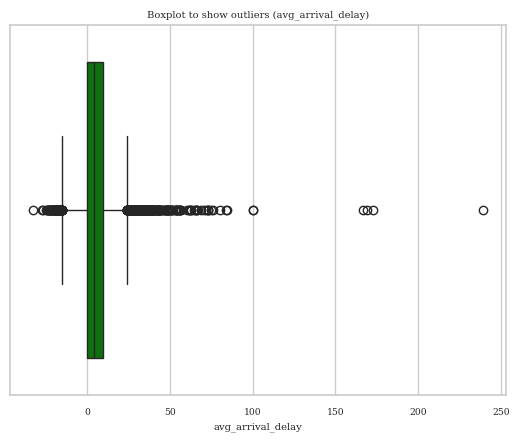

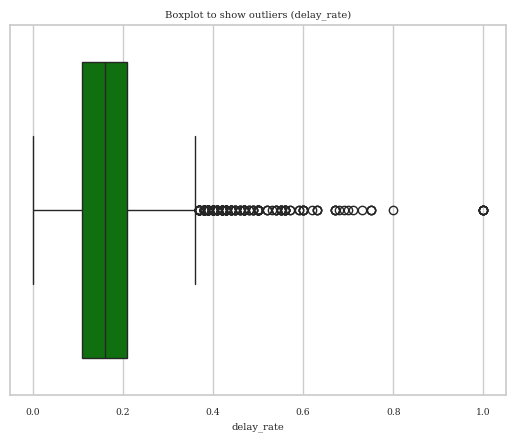

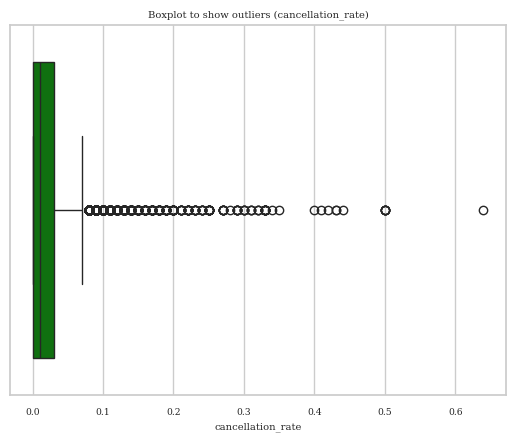

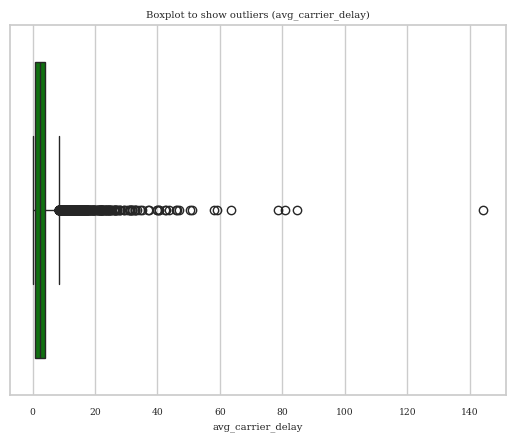

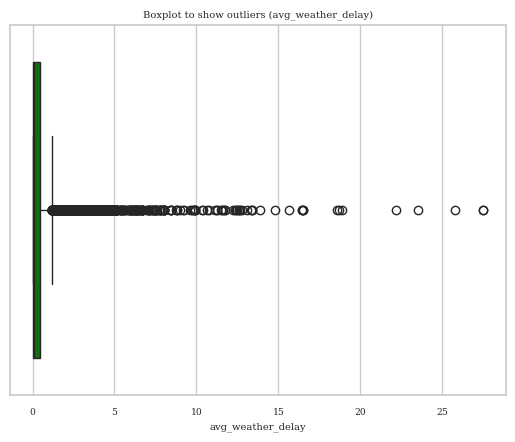

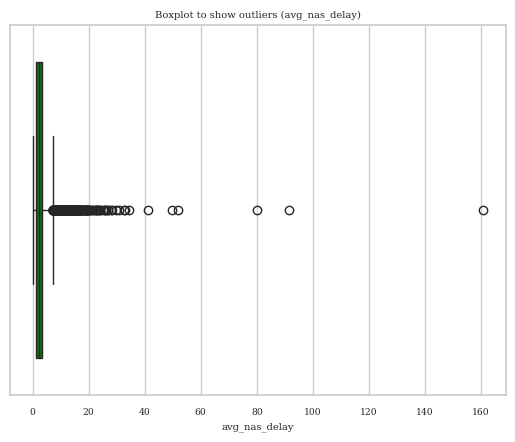

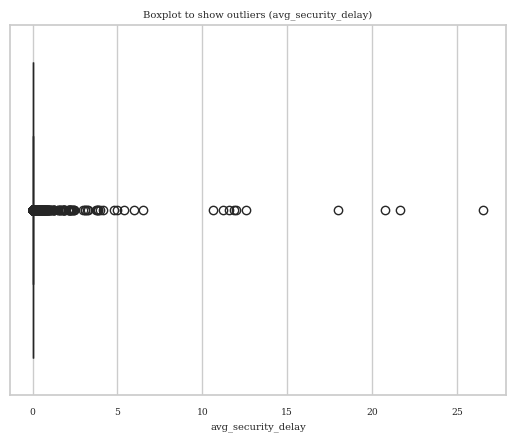

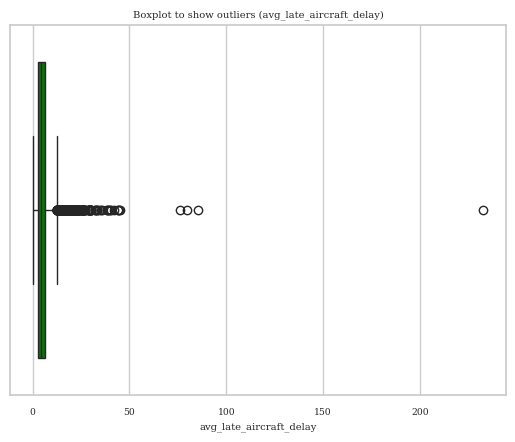

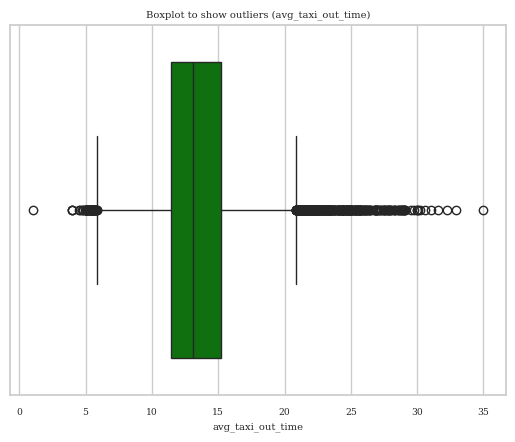

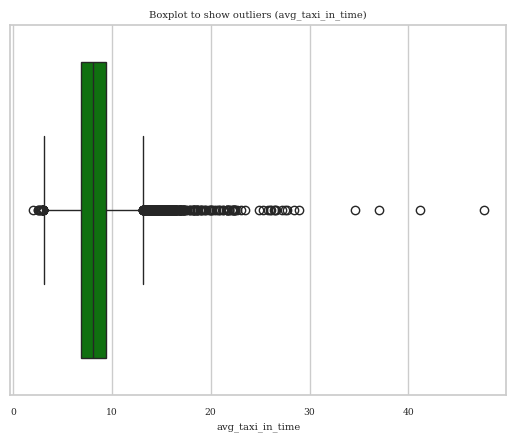

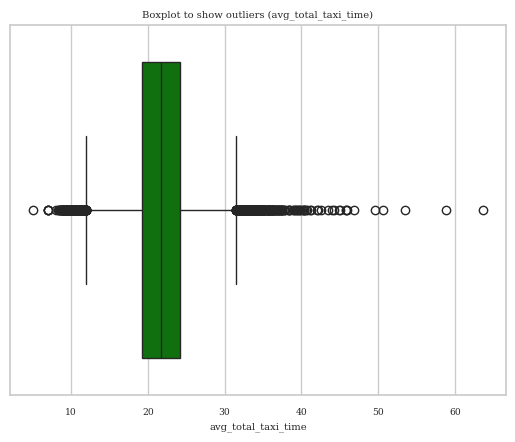

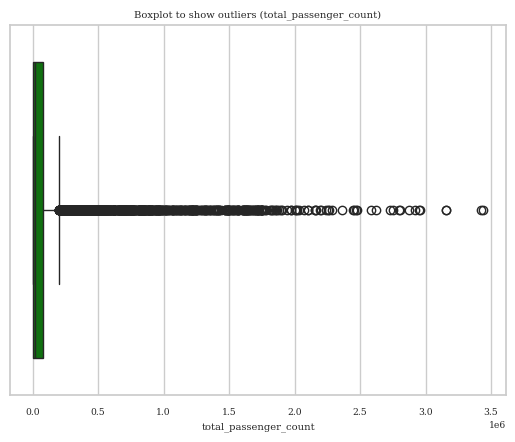

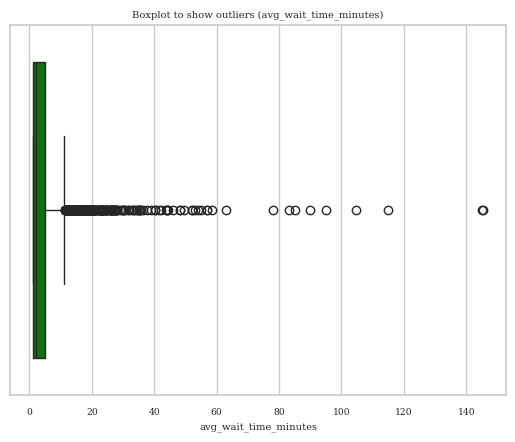

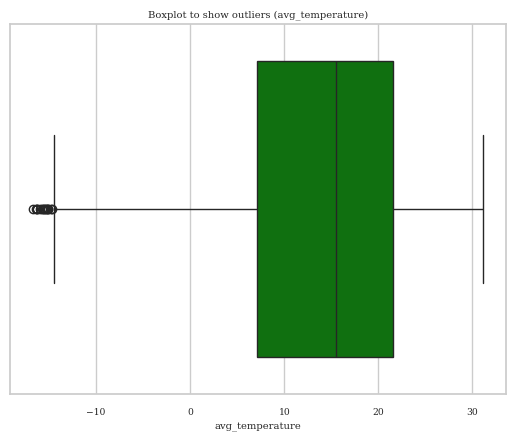

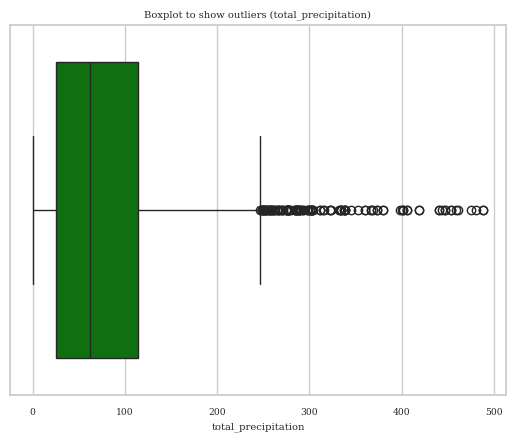

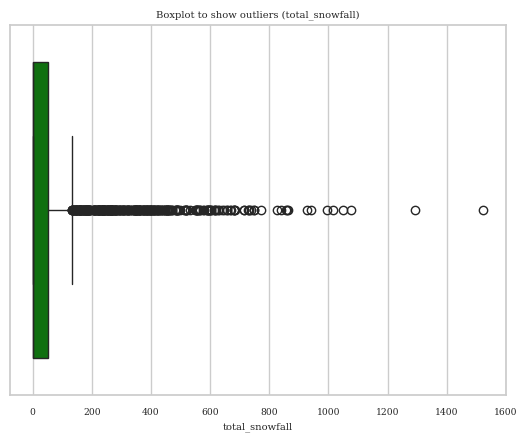

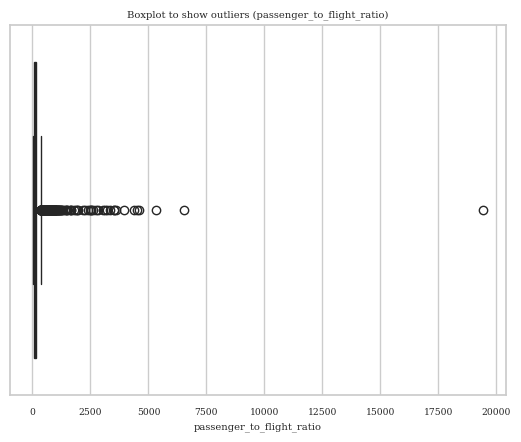

In [23]:
for col in columns:
    sns.boxplot(x=gold_df[col], color='green')
    plt.title(f"Boxplot to show outliers ({col})")
    plt.show()

### SECTION 5 - Bivariate Analysis

##### Scatterplot

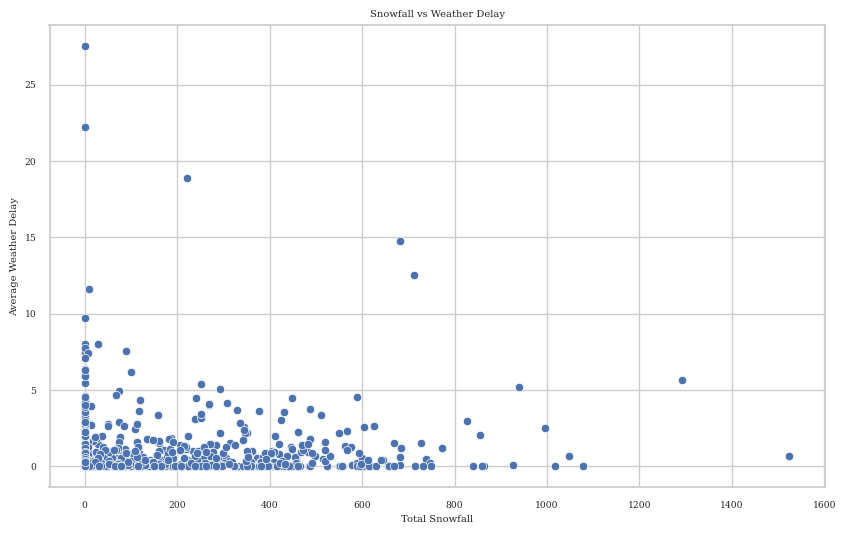

In [24]:
# Snowfall vs Weather Delay

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=gold_df,
    x="total_snowfall",
    y="avg_weather_delay"
)

plt.title("Snowfall vs Weather Delay")

plt.xlabel("Total Snowfall")
plt.ylabel("Average Weather Delay")

plt.show()

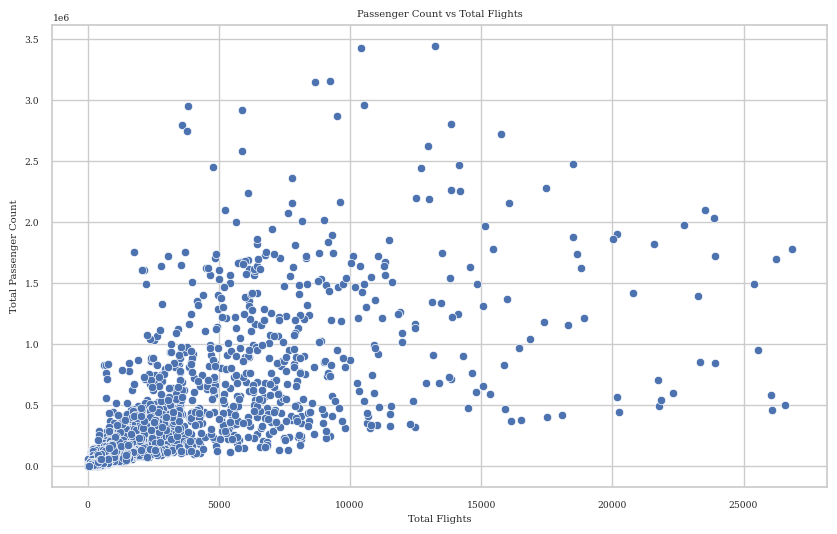

In [25]:
# Passenger Count vs Total Flights

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=gold_df,
    x="total_flights",
    y="total_passenger_count"
)

plt.title("Passenger Count vs Total Flights")

plt.xlabel("Total Flights")
plt.ylabel("Total Passenger Count")

plt.show()

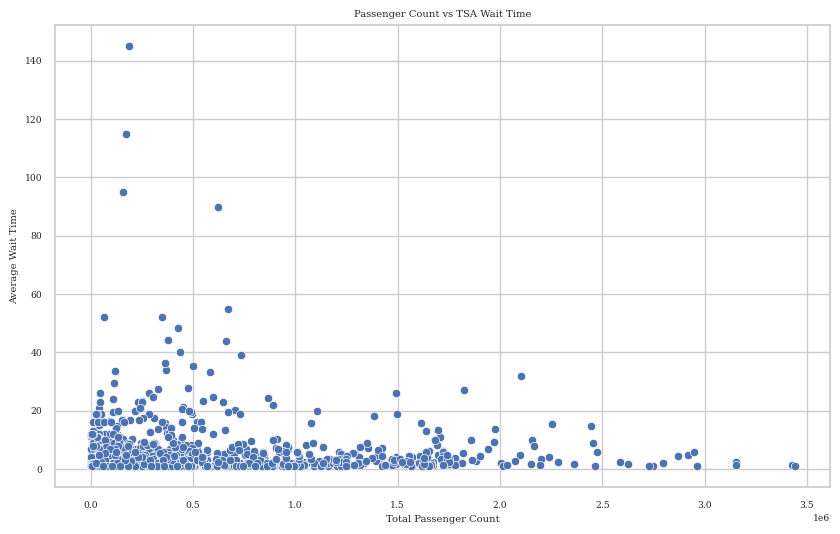

In [26]:
# Passenger Count vs TSA Wait Time

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=gold_df,
    x="total_passenger_count",
    y="avg_wait_time_minutes"
)

plt.title("Passenger Count vs TSA Wait Time")

plt.xlabel("Total Passenger Count")
plt.ylabel("Average Wait Time")

plt.show()

##### Pairwise Correlation Matrix

In [27]:
# Measures the direction and strength of a relationship between two variables
#
# | Correlation | Meaning                       |
# | ----------- | ----------------------------- |
# | +1          | perfect positive relationship |
# | 0           | no relationship               |
# | -1          | perfect negative relationship |


numeric_cols = gold_df.select_dtypes(include=np.number)
corr_matrix = numeric_cols.corr()

corr_matrix

,month,total_flights,avg_departure_delay,avg_arrival_delay,delay_rate,cancellation_rate,avg_carrier_delay,avg_weather_delay,avg_nas_delay,avg_security_delay,avg_late_aircraft_delay,avg_taxi_out_time,avg_taxi_in_time,avg_total_taxi_time,total_passenger_count,avg_wait_time_minutes,avg_temperature,total_precipitation,total_snowfall,passenger_to_flight_ratio
month,1.000000,0.000337,-0.044516,-0.049272,-0.068991,-0.156580,-0.012375,-0.036399,-0.009304,0.021959,-0.052886,-0.020012,0.001816,-0.014368,-0.109141,0.024554,0.225207,0.078498,-0.232276,-0.092077
total_flights,0.000337,1.000000,0.114523,0.029624,0.168491,-0.098956,0.050652,-0.004976,-0.009403,-0.017682,-0.024209,0.281386,-0.201135,0.105212,0.753984,0.168678,0.013515,-0.056452,-0.010694,-0.027904
avg_departure_delay,-0.044516,0.114523,1.000000,0.917751,0.765996,0.273829,0.557328,0.233155,0.514106,0.047225,0.678091,0.210869,0.178184,0.260296,0.126380,0.096364,0.006801,0.069313,0.117580,-0.070836
avg_arrival_delay,-0.049272,0.029624,0.917751,1.000000,0.731494,0.307208,0.520144,0.240746,0.590771,0.057907,0.671180,0.211614,0.249971,0.299223,0.013738,0.036317,-0.020856,0.080485,0.140577,-0.088533
delay_rate,-0.068991,0.168491,0.765996,0.731494,1.000000,0.287818,0.275669,0.155397,0.407932,0.158002,0.583020,0.144278,0.104159,0.169364,0.172680,0.108073,-0.006594,0.045532,0.112822,-0.081584
cancellation_rate,-0.156580,-0.098956,0.273829,0.307208,0.287818,1.000000,0.050420,0.136622,0.215657,0.026018,0.173899,0.138330,0.208183,0.220086,-0.101439,-0.034940,-0.314791,-0.043047,0.337002,-0.041550
avg_carrier_delay,-0.012375,0.050652,0.557328,0.520144,0.275669,0.050420,1.000000,0.050895,0.083935,-0.008294,0.057404,0.154865,0.118354,0.183475,0.059223,0.040216,-0.033356,0.017430,0.107574,-0.028718
avg_weather_delay,-0.036399,-0.004976,0.233155,0.240746,0.155397,0.136622,0.050895,1.000000,0.075454,-0.003582,0.058495,0.105607,0.089280,0.129840,0.011787,0.016498,-0.092126,0.022624,0.127967,-0.043506
avg_nas_delay,-0.009304,-0.009403,0.514106,0.590771,0.407932,0.215657,0.083935,0.075454,1.000000,-0.005694,0.215093,0.263931,0.277207,0.354162,-0.012583,-0.005042,-0.022256,0.100638,0.126317,-0.035073
avg_security_delay,0.021959,-0.017682,0.047225,0.057907,0.158002,0.026018,-0.008294,-0.003582,-0.005694,1.000000,-0.025554,-0.065742,-0.084328,-0.096627,-0.019488,0.009237,-0.002335,-0.016333,-0.036162,-0.015774


##### Heatmap

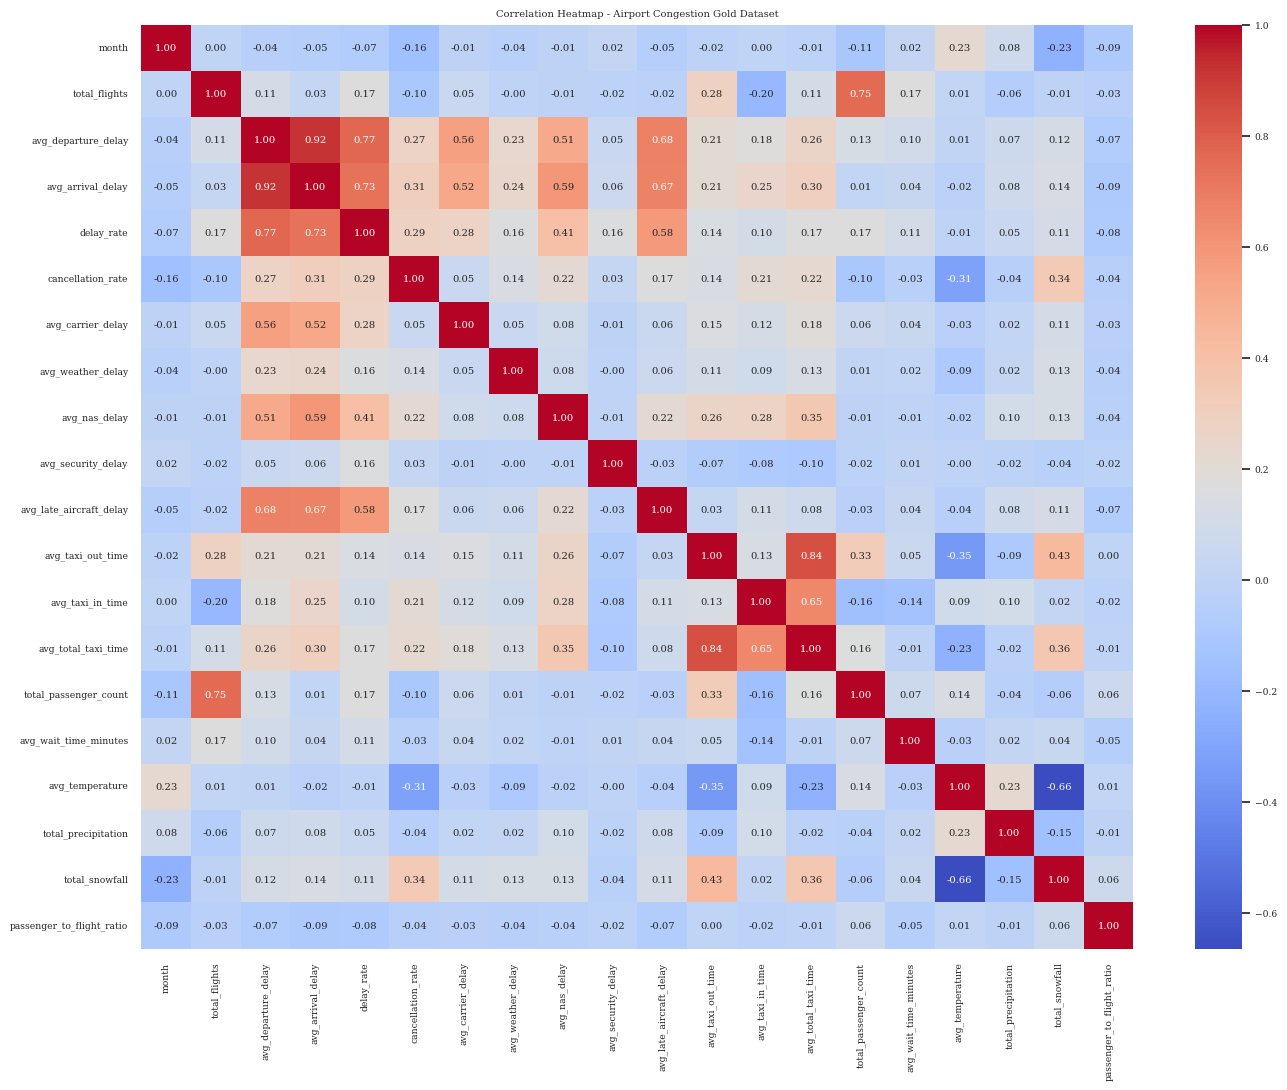

In [28]:
# Full correlation heatmap

# | Color       | Interpretation              |
# | ----------- | --------------------------- |
# | dark red    | strong positive correlation |
# | dark blue   | strong negative correlation |
# | light/white | weak correlation            |


plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap - Airport Congestion Gold Dataset")

plt.show()

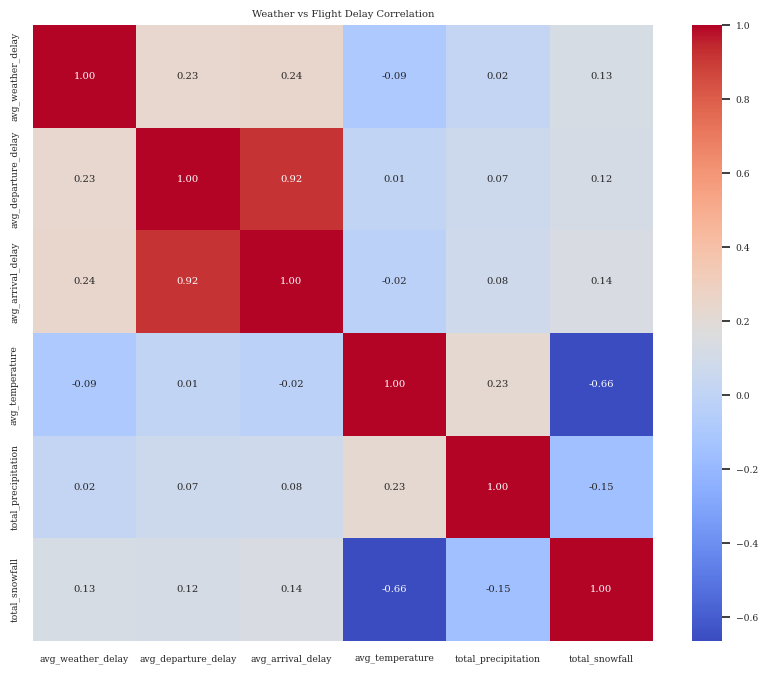

In [29]:
# Weather vs Delay Correlation Heatmap

weather_delay_cols = [
    "avg_weather_delay",
    "avg_departure_delay",
    "avg_arrival_delay",
    "avg_temperature",
    "total_precipitation",
    "total_snowfall"
]

weather_delay_corr = gold_df[
    weather_delay_cols
].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    weather_delay_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Weather vs Flight Delay Correlation")

plt.show()

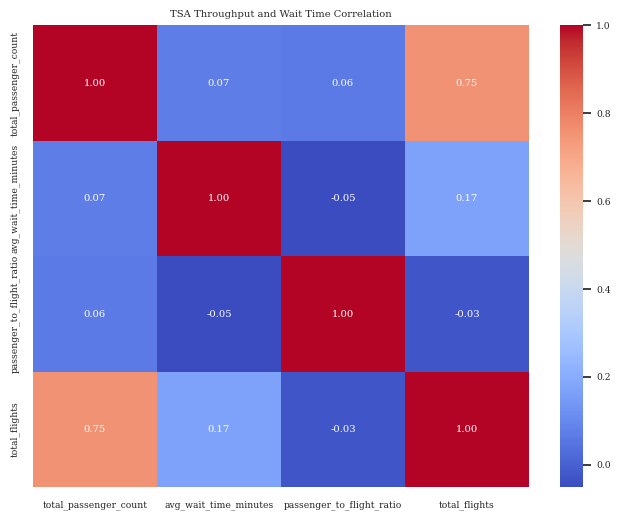

In [30]:
# TSA Throughput vs Wait Time Heatmap

tsa_cols = [
    "total_passenger_count",
    "avg_wait_time_minutes",
    "passenger_to_flight_ratio",
    "total_flights"
]

tsa_corr = gold_df[tsa_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    tsa_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("TSA Throughput and Wait Time Correlation")

plt.show()

### SECTION 6 - Time-series Trend Analysis

##### Monthly Trends

C:\Users\kyuen\AppData\Local\Temp\ipykernel_30220\3626691827.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["year", "month"])["avg_departure_delay"]


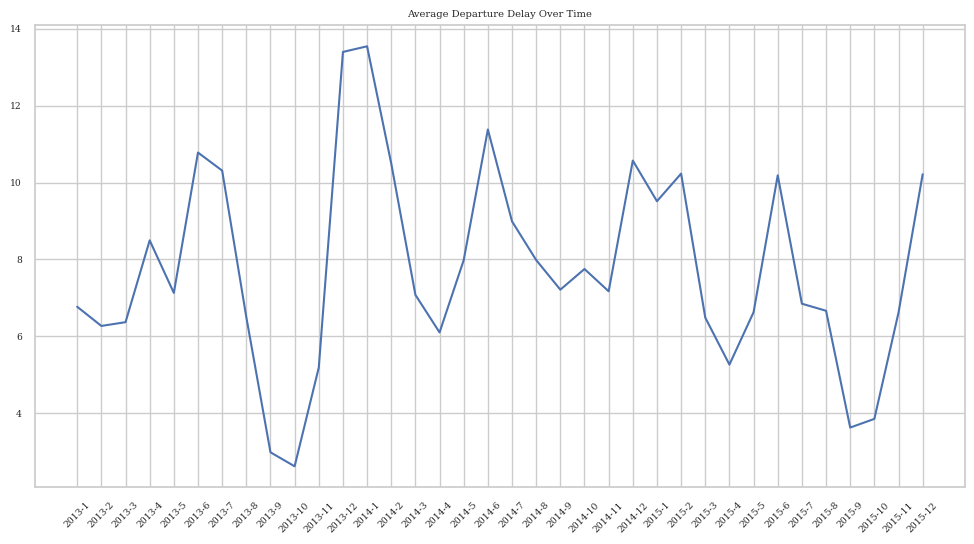

In [31]:
monthly_delay_trend = (
    gold_df
    .groupby(["year", "month"])["avg_departure_delay"]
    .mean()
    .reset_index()
)

monthly_delay_trend["year_month"] = (
    monthly_delay_trend["year"].astype(str)
    + "-"
    + monthly_delay_trend["month"].astype(str)
)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_delay_trend["year_month"],
    monthly_delay_trend["avg_departure_delay"]
)

plt.xticks(rotation=45)

plt.title("Average Departure Delay Over Time")

plt.show()

##### Seasonal Pattern

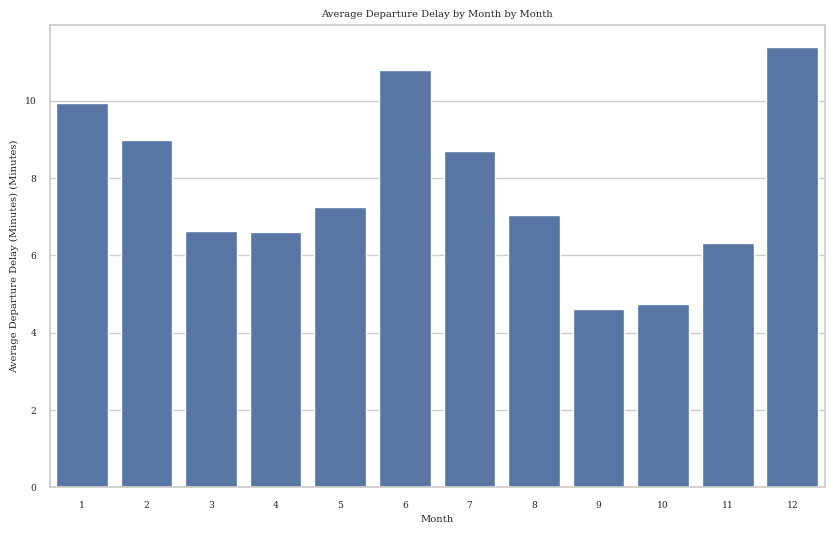

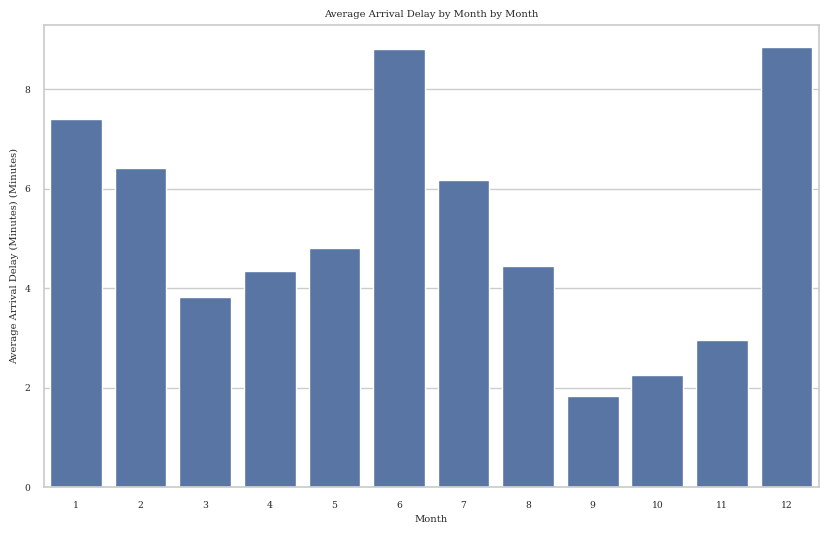

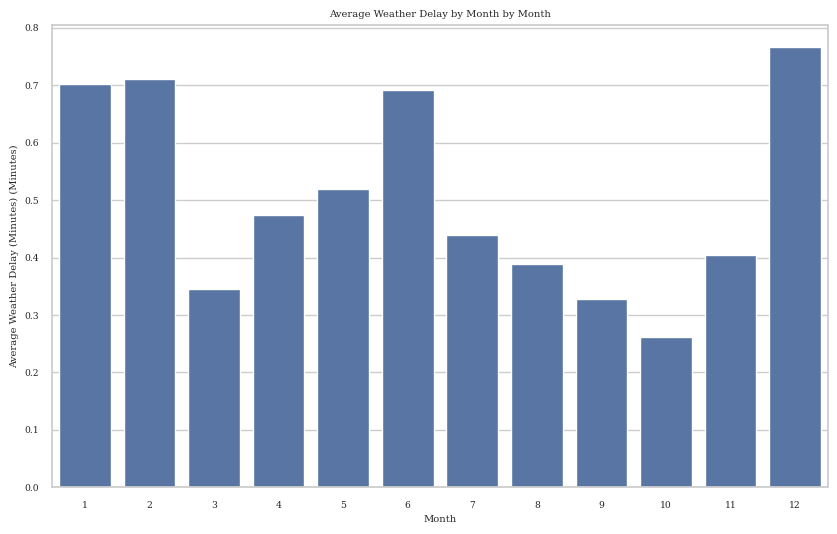

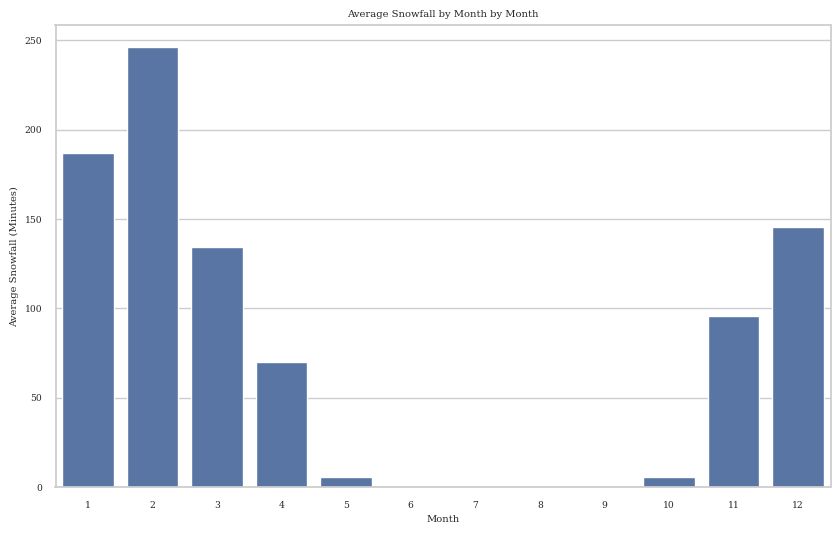

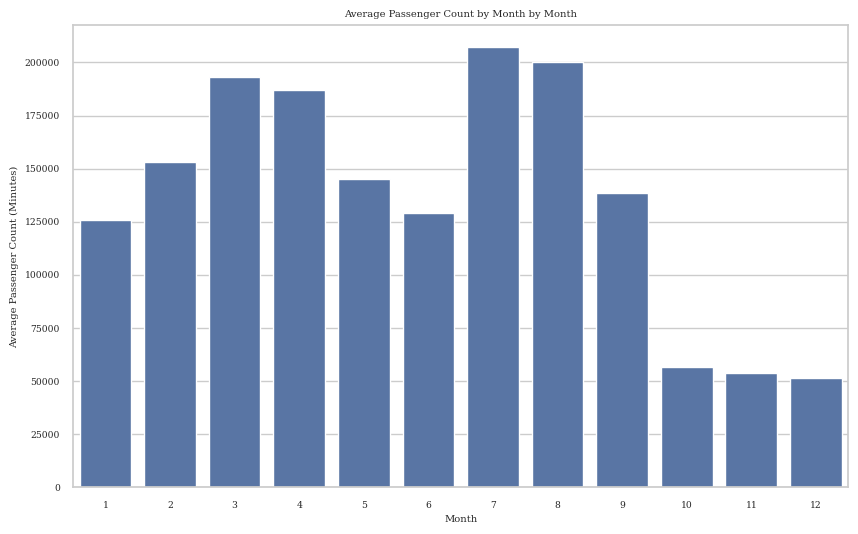

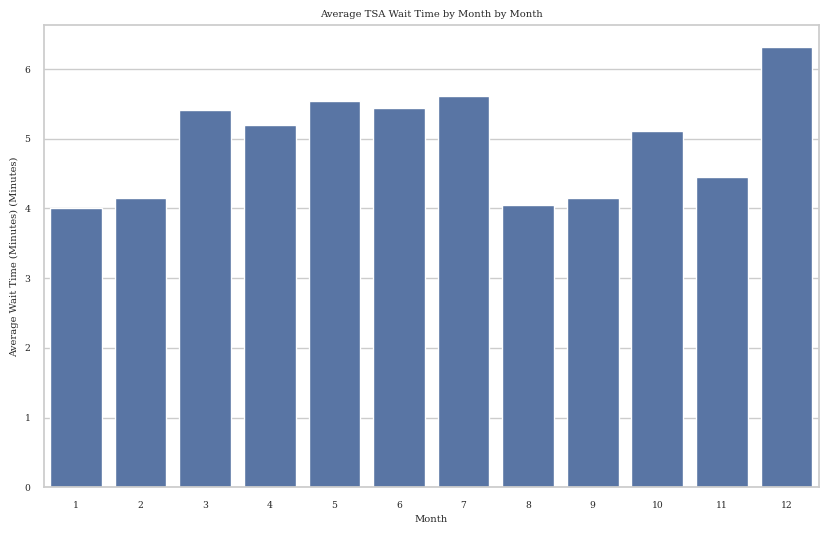

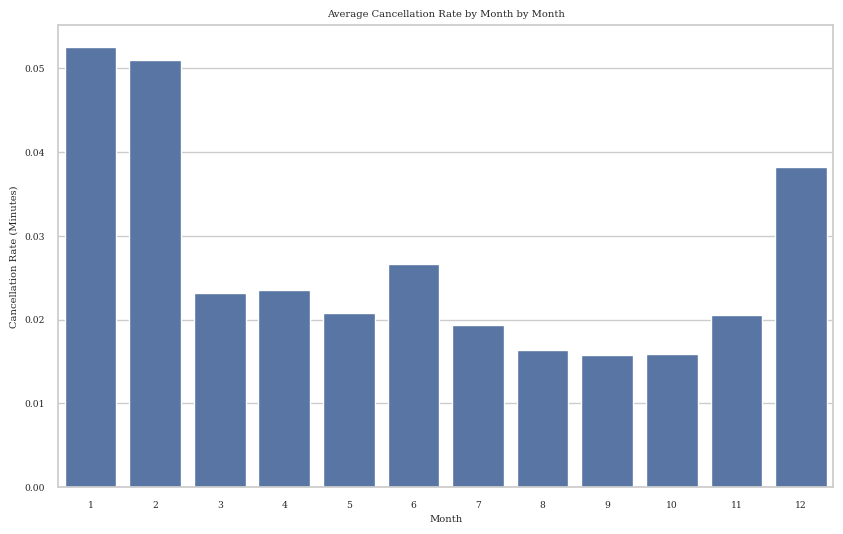

In [32]:
def seasonal_analysis(column, title, ylabel):
    monthly = (
        gold_df
        .groupby("month")[column]
        .mean()
        .reset_index()
    )
    
    plt.figure(figsize=(10, 6))
    
    sns.barplot(
        data=monthly,
        x="month",
        y=column
    )
    
    plt.title(f"{title} by Month")
    plt.xlabel("Month")
    plt.ylabel(f"{ylabel} (Minutes)")
    
    plt.show()

# Average Departure Delay by Month
seasonal_analysis("avg_departure_delay", "Average Departure Delay by Month", "Average Departure Delay (Minutes)")
# Average Arrival Delay by Month
seasonal_analysis("avg_arrival_delay", "Average Arrival Delay by Month", "Average Arrival Delay (Minutes)")
# Weather Delay by Month
seasonal_analysis("avg_weather_delay", "Average Weather Delay by Month", "Average Weather Delay (Minutes)")
# Total Snowfall by Month
seasonal_analysis("total_snowfall", "Average Snowfall by Month", "Average Snowfall")
# Passenger Throughput by Month
seasonal_analysis("total_passenger_count", "Average Passenger Count by Month", "Average Passenger Count")
# TSA Wait Time by Month
seasonal_analysis("avg_wait_time_minutes", "Average TSA Wait Time by Month", "Average Wait Time (Minutes)")
# Cancellation Rate by Month
seasonal_analysis("cancellation_rate", "Average Cancellation Rate by Month", "Cancellation Rate")

### SECTION 7 - ML Readiness

##### Multicollinearity Analysis

In [33]:
# Identify redundant features

# | VIF    | Interpretation        |
# | ------ | --------------------- |
# | 1      | no multicollinearity  |
# | 1 – 5  | low/moderate          |
# | 5 – 10 | high                  |
# | > 10   | very high/problematic |
# | >> 100 | severe redundancy     |

features = gold_df.select_dtypes(include=np.number).dropna()

vif_df = pd.DataFrame()

vif_df["feature"] = features.columns

vif_df["VIF"] = [
    variance_inflation_factor(
        features.values,
        i
    )
    for i in range(features.shape[1])
]

vif_df["VIF"] = vif_df["VIF"].round(2)

vif_df = vif_df.sort_values(by="VIF", ascending=False)

vif_df.style.format({"VIF": "{:,.2f}"})

,feature,VIF
13,avg_total_taxi_time,"27,087,578.74"
11,avg_taxi_out_time,"11,386,749.55"
12,avg_taxi_in_time,"3,508,007.09"
2,avg_departure_delay,107.31
4,delay_rate,77.25
10,avg_late_aircraft_delay,55.60
6,avg_carrier_delay,29.86
8,avg_nas_delay,18.70
3,avg_arrival_delay,18.33
0,month,10.21


##### Skewness Interpretation

In [34]:
numeric_df = gold_df.select_dtypes(include=np.number)

skewness_df = pd.DataFrame({
    "feature": numeric_df.columns,
    "skewness": numeric_df.skew().values
})

skewness_df = skewness_df.sort_values(by="skewness", ascending=False)
skewness_df

,feature,skewness
9,avg_security_delay,32.116871
19,passenger_to_flight_ratio,30.678220
8,avg_nas_delay,15.137753
10,avg_late_aircraft_delay,13.343797
6,avg_carrier_delay,9.407572
7,avg_weather_delay,7.905239
15,avg_wait_time_minutes,7.137416
1,total_flights,4.512736
14,total_passenger_count,4.328049
5,cancellation_rate,4.089063


##### Scaling

In [35]:
scaling_df = pd.DataFrame({
    "feature": numeric_df.columns,
    "min": numeric_df.min().values,
    "max": numeric_df.max().values,
    "mean": numeric_df.mean().values,
    "std": numeric_df.std().values
})

scaling_df

,feature,min,max,mean,std
0,month,1.00,12.00,6.500633,3.444378
1,total_flights,1.00,26854.00,1092.887964,2604.408485
2,avg_departure_delay,-22.64,234.75,7.763800,9.089785
3,avg_arrival_delay,-33.00,239.50,5.186350,10.267886
4,delay_rate,0.00,1.00,0.164952,0.088524
5,cancellation_rate,0.00,0.64,0.026984,0.041525
6,avg_carrier_delay,0.00,144.40,3.031886,4.059419
7,avg_weather_delay,0.00,27.52,0.502994,1.319719
8,avg_nas_delay,0.00,160.88,2.752476,3.305040
9,avg_security_delay,0.00,26.57,0.035158,0.535678


##### Encoding Considerations

In [36]:
categorical_cols = gold_df.select_dtypes(exclude=np.number).columns

for col in categorical_cols:
    print(f"\n{col}")
    print(gold_df[col].nunique())


iata_code
337

year
3


##### Feature Importance Candidates

In [37]:
target_corr = corr_matrix[["delay_rate"]].sort_values(by="delay_rate", ascending=False)

target_corr

,delay_rate
delay_rate,1.000000
avg_departure_delay,0.765996
avg_arrival_delay,0.731494
avg_late_aircraft_delay,0.583020
avg_nas_delay,0.407932
cancellation_rate,0.287818
avg_carrier_delay,0.275669
total_passenger_count,0.172680
avg_total_taxi_time,0.169364
total_flights,0.168491


### SECTION 8 - Key Findings

##### 1. Dataset Structure and Coverage

- The airport_congestion_gold dataset successfully integrates flight performance, TSA throughput, TSA wait time, airport metadata, and 
weather information into a unified analytical dataset.
- The dataset covers multiple airports across monthly periods from 2013–2015, providing sufficient temporal coverage for predictive modeling 
and trend analysis.
- Composite primary keys (iata_code, year, month) showed strong uniqueness with minimal data quality concerns.

##### 2. Data Quality Observations

- No major duplicate issues were identified in the final gold dataset.
- Null values were primarily concentrated in TSA throughput, wait time, and weather-related features, which aligns with missing upstream 
source data rather than ETL failures.
- Missing data patterns appeared systematic rather than random, particularly for smaller airports and earlier years.

##### 3. Distribution and Variability Insights
- Several operational metrics exhibited high variability, including:
  - total_flights
  - total_passenger_count
  - avg_departure_delay
  - avg_arrival_delay
- Weather-related variables such as total_snowfall and avg_weather_delay showed strong positive skewness, indicating that most airport-month 
combinations experience low weather impact while a smaller subset experiences extreme events.
- Delay-related metrics displayed significant right-skewed distributions, suggesting the presence of operational outliers and irregular 
congestion events.

##### 4. Correlation and Relationship Findings
- Strong positive correlations were observed between:
  - departure delay and arrival delay
  - total flights and passenger throughput
  - snowfall and weather delays
- TSA throughput metrics demonstrated moderate relationships with TSA wait times, suggesting that higher passenger volumes may contribute to 
congestion but are not the sole driver.
- Weather variables exhibited measurable relationships with operational delays, particularly snowfall and precipitation metrics.

##### 5. Seasonal and Temporal Patterns
- Seasonal analysis indicated observable monthly fluctuations in:
  - passenger throughput
  - total flights
  - weather-related delays
- Winter months generally showed higher snowfall and weather-related operational disruption.
- Some airports demonstrated stronger seasonal congestion patterns than others, suggesting airport-specific operational behavior.

##### 6. Multicollinearity and Feature Redundancy
- Variance Inflation Factor (VIF) analysis revealed substantial multicollinearity among delay-related features.
- Extremely high VIF values were identified for:
  - avg_total_taxi_time
  - avg_taxi_out_time
  - avg_taxi_in_time
- This indicates near-linear dependency among taxi-related metrics and suggests potential feature reduction before model training.

##### 7. Machine Learning Readiness
- Several features appear to be strong predictive candidates for congestion-related modeling, including:
  - weather delay metrics
  - snowfall
  - passenger throughput
  - wait time metrics
- Many numeric features exist on significantly different scales, indicating that feature scaling may be required for certain ML algorithms.
- Categorical features such as iata_code will require encoding during preprocessing.

### SECTION 9 - Next Steps

##### 1. Feature Engineering

The next stage of the project will focus on preparing the dataset for machine learning model development. Planned feature engineering tasks 
include:

  - handling missing values
  - encoding categorical variables (iata_code)
  - scaling and normalization of numeric features
  - outlier treatment and transformation of highly skewed variables
  - feature reduction for highly collinear variables
  - creation of temporal and seasonal features

##### 2. Feature Selection

Additional analysis will be performed to identify the most informative predictive features while minimizing redundancy and target leakage. 
This may include:

  - correlation-based feature selection
  - recursive feature elimination

##### 3. Machine Learning Pipeline Development

The prepared dataset will be used to train and evaluate multiple machine learning models for airport congestion prediction, including:

  - Linear Regression
  - Random Forest

Model evaluation metrics may include:

  - RMSE
  - R² score

depending on the final prediction target.

##### 4. Model Evaluation and Optimization

Include:

  - hyperparameter tuning
  - performance comparison across models
  - overfitting and bias-variance analysis